# Одномерная оптимизация (10 баллов)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

sns.set()
%config InlineBackend.figure_format = 'retina'

В данном домашнем задании рассмотриваются несколько базовых подходов одномерной оптимизации, не использующих знания о градиенте функции. Для его выполнения потребуется следующее определение:

__Определение.__ Одномерная функция $f: [a, b] \to \mathbb{R}$ называется _унимодальной_ на $[a, b]$, если существует $c^{*} \in [a, b]$ такое, что:

1. Для произвольных $x, y \in [a, c^{*}]$, таких что $x < y$, выполнено $f(x) > f(y)$;

2. Для произвольных $x, y \in [c^{*}, b]$, таких что $x < y$, выполнено $f(x) < f(y)$.

Говоря менее формально, мы рассматриваем функции на отрезке, которые строго убывают слева от минимума и строго возрастают справа от него. Из определения незамедлительно следует, что минимум на отрезке $[a, b]$ единственен.

Описание метода __дихотомии__ (бисекции) для поиска минимума унимодальных функций:

1. __Инициализация:__

1.1. Задается унимодальная функция $f(x)$, которая имеет единственный минимум на интервале $[a,b]$.

1.2. Задается начальный интервал $[a,b]$, на котором ищется минимум.

1.3. Задается параметр $\varepsilon$ — точность, с которой нужно найти минимум.

2. __Итеративный шаг метода:__

2.1. Интервал $[a,b]$ делится пополам, и вычисляется середина интервала:

$$c = \frac{a + b}{2}$$

2.2. Выбираются две точки $x_1$ и $x_2$, близкие к середине интервала $c$, но не совпадающие с ней:

$$x_{1} = c - \delta, \quad x_{2} = c + \delta,$$

где $\delta$ небольшое положительное число, обычно $\delta \ll \varepsilon$, поэтому возьмите $\delta = \frac{\varepsilon}{10}$.

2.3. Вычисляются значения функции в точках $x_1$ и $x_2$:

$\bullet$ Если $f(x_{1}) < f(x_{2})$, то минимум находится на отрезке $[a, x_{2}]$, поэтому зона поиска оптимума сужается до $[a, x_2]$.

$\bullet$ Если $f(x_{1}) > f(x_{2})$, то минимум находится на отрезке $[x_{1}, b]$, поэтому зона поиска оптимума сужается до $[x_1, b]$.

$\bullet$ Если $f(x_{1}) = f(x_{2})$, то минимум находится на отрезке $[x_{1}, x_{2}]$, поэтому зона поиска оптимума сужается до $[a, x_{2}]$ или $[x_1, b]$.

3. __Проверка точности:__

$\bullet$ Если длина нового интервала меньше заданной точности $\varepsilon$, то процесс завершается и возвращается значение $c_{\text{out}}$ ($c$ с последней итерации).

$\bullet$ Если длина нового интервала больше заданной точности $\varepsilon$, то повторяется шаг 2 для нового интервала.

__а) (0.5 балла)__ Докажите, что данный алгоритм находит минимум унимодальной функции на отрезке $[a, b]$ с точностью $\varepsilon$ . 

#### Ваше решение (Markdown)
на каждой итерации алгоритма, область поиска ссужается почти что в 2 раза (ну на самом деле отрезается кусок $ \frac{l}{2} - \delta $ где $ l = |[a, b]|$)
 

$ l \rightarrow \frac{l}{2} + \delta \rightarrow \frac{\frac{l}{2} + \delta}{2} + \delta \rightarrow ... \rightarrow l * \frac{1}{2^{k}} + (2 - \frac{1}{k+1}) * \delta$

ясно что при достаточно большом $ k $ длина отрезка будет меньше чем $ \epsilon $


__б) (0.5 балла)__ Какова будет итерационная и оракульная сложность данного алгоритма для достижения точности $\varepsilon$ (а именно, $|c_{\text{out}} - c^*| \leq \varepsilon$)?

Необходимо получить верхнюю оценку на число итераций и подсчета значений $f$ метода дихотомии для минимизации унимодальных функций.

__Замечание__. Величиной $\delta$ надо пренебречь.

#### Ваше решение (Markdown)

пренебригая $ \delta $ то заметим что длина отрезка уменьшается в два раза $ l_{k + 1} = \frac{l_{k}}{{2}}$ где $l = |[a, b]|  $

алгоритм останавливается когда $ |l_{N}| < \epsilon $

давайте найдем $ N $

$$ l_{N} = \frac{l}{2^{N}} \leq \epsilon $$
$$ N \geq log_{2}(\frac{l}{2}) $$ 

то есть всего итерации $log_{2}(\frac{l}{2})$

во время одной итерации в ывысчитываем $ f(x_1), f(x_2) $ всего 2 операции. То есть оракульная сложность = $2log_{2}(\frac{l}{2})$

__в) (1 балл)__ Придумайте свою унимодальную функцию на отрезке. 

1. Покажите, что она является унимодальной на этом отрезке (аналитически).

2. Найдите $c^{*}$ (аналитически).

3. Нарисуйте график функции.

#### Ваше решение (Markdown)
1. Рассмотрим функцию $f(x) = x^2$ на отрезке $[-1, 1]$. Покажем что она унимодальная

$ \forall x \in [-1, 0) \rightarrow f'(x) = 2x < 0 $  -  функция монотонно убывает на промежутке $[-1, 0)$

$ \forall x \in (0, 1] \rightarrow f'(x) = 2x > 0 $  -  функция монотонно возрастает на промежутке $[0, 1)$

видно что функция убывает на $ [-1, 0] $ и возрастает на $ [0, 1] $ что характеризует ее как унимодальную функцию

2. f - дифференцируема на всем промежутке, и так как она унимодальная то у нее единственный минимум

$ f'(x) = 0 \rightarrow x = 0 $

получается $ c^{*} $ = 0

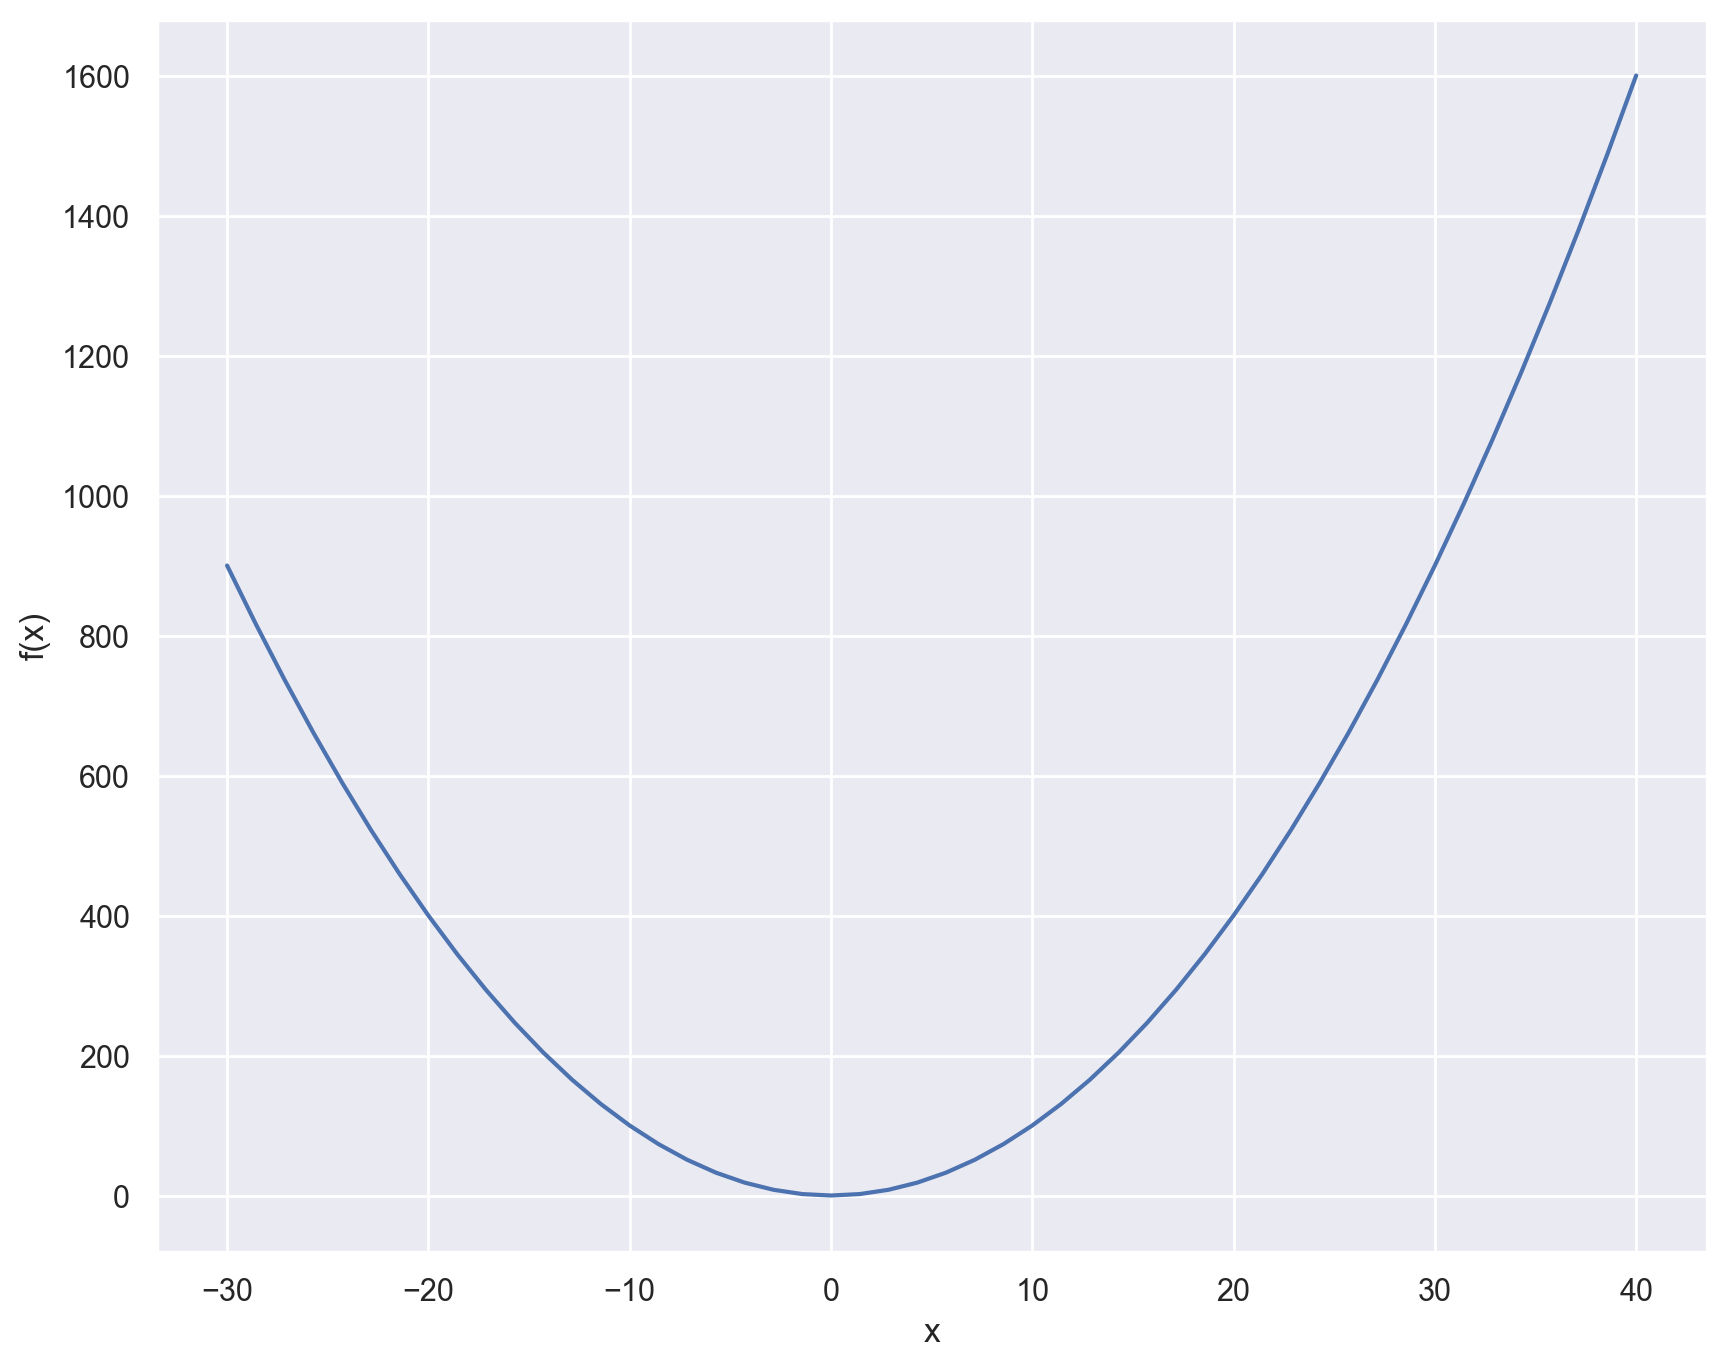

In [2]:
func = lambda x : x**2

grid = np.linspace(-30, 40)

plt.figure(figsize = (10, 8))
plt.plot(grid, func(grid))
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

__г) (1.5 балла)__ Реализуйте метод дихотомии.

In [3]:
def dichotomy_method(f, a, b, c_star, max_iter=100, epsilon=1e-6, **params):
    """
    Метод дихотомии для поиска минимума унимодальной функции на интервале [a, b].

    Параметры:
        f (callable): Унимодальная функция, минимум которой ищется.
        a (float): Левая граница интервала поиска.
        b (float): Правая граница интервала поиска.
        c_star (float): Истинное значение точки минимума (для сравнения).
        max_iter (int, optional): Максимальное количество итераций. По умолчанию 100.
        epsilon (float, optional): Точность поиска. 
            Поиск завершается, когда длина интервала становится меньше epsilon. По умолчанию 1e-6.
        **params: Именованные гиперпараметры метода.
            params['delta'] - значение гиперпараметра для поиска точек x1 и x2.

    Возвращает:
        c (float): Приближенное значение точки минимума.
        history (list): Список значений |c - c_star| на каждой итерации.
    """
    
    if a >= b:
        raise ValueError("Левая граница интервала a должна быть меньше правой границы b.")
    if epsilon <= 0:
        raise ValueError("Точность epsilon должна быть положительной.")
        
    history = []
    f_call = 0
    f_call_list = []
    left = a
    right = b
    delta = params["delta"]
    iter = 0

    while(right - left > epsilon and iter <= max_iter): #   np.abs(left + (right - left) / 2 - c_star)
        c = left + (right - left) / 2
        f1 = f(c - delta)
        f2 = f(c + delta)
        f_call += 2
        f_call_list.append(f_call)        
        history.append(np.abs(c - c_star))
        
        if(f1 < f2):
            right = c + delta
        else: 
            left = c - delta # здесь я совместил условия на f1 == f2 и f1 > f2 так как по алгоритму мы можем использовать один из двух вариантов по умолчанию
        iter += 1

    return c, history, f_call_list

In [4]:
c, history, _ = dichotomy_method(func, -30, 40, 0, delta = 1e-7)

print(f"приближенный методом минимум = {np.round(c, 5)}")
print(f"всего итерации {len(history)}")

приближенный методом минимум = -0.0
всего итерации 27


Постройте сравнительный график зависимости точности метода $|c_{\text{out}} - c^*|$ и теоретической оценки от числа итераций. Значение $\delta$ выберите равным $10^{-8} \cdot (b - a)$. График должен соответствовать следующим критериям:

1. Размер должен быть удобен для чтения
2. Масштаб осей (обычный или логарифмический)
3. Подписи осей 
4. Легенда (так как на графике несколько линий)
5. Толщина/цвет/сетка (на ваше усмотрение, но должно быть читаемо)

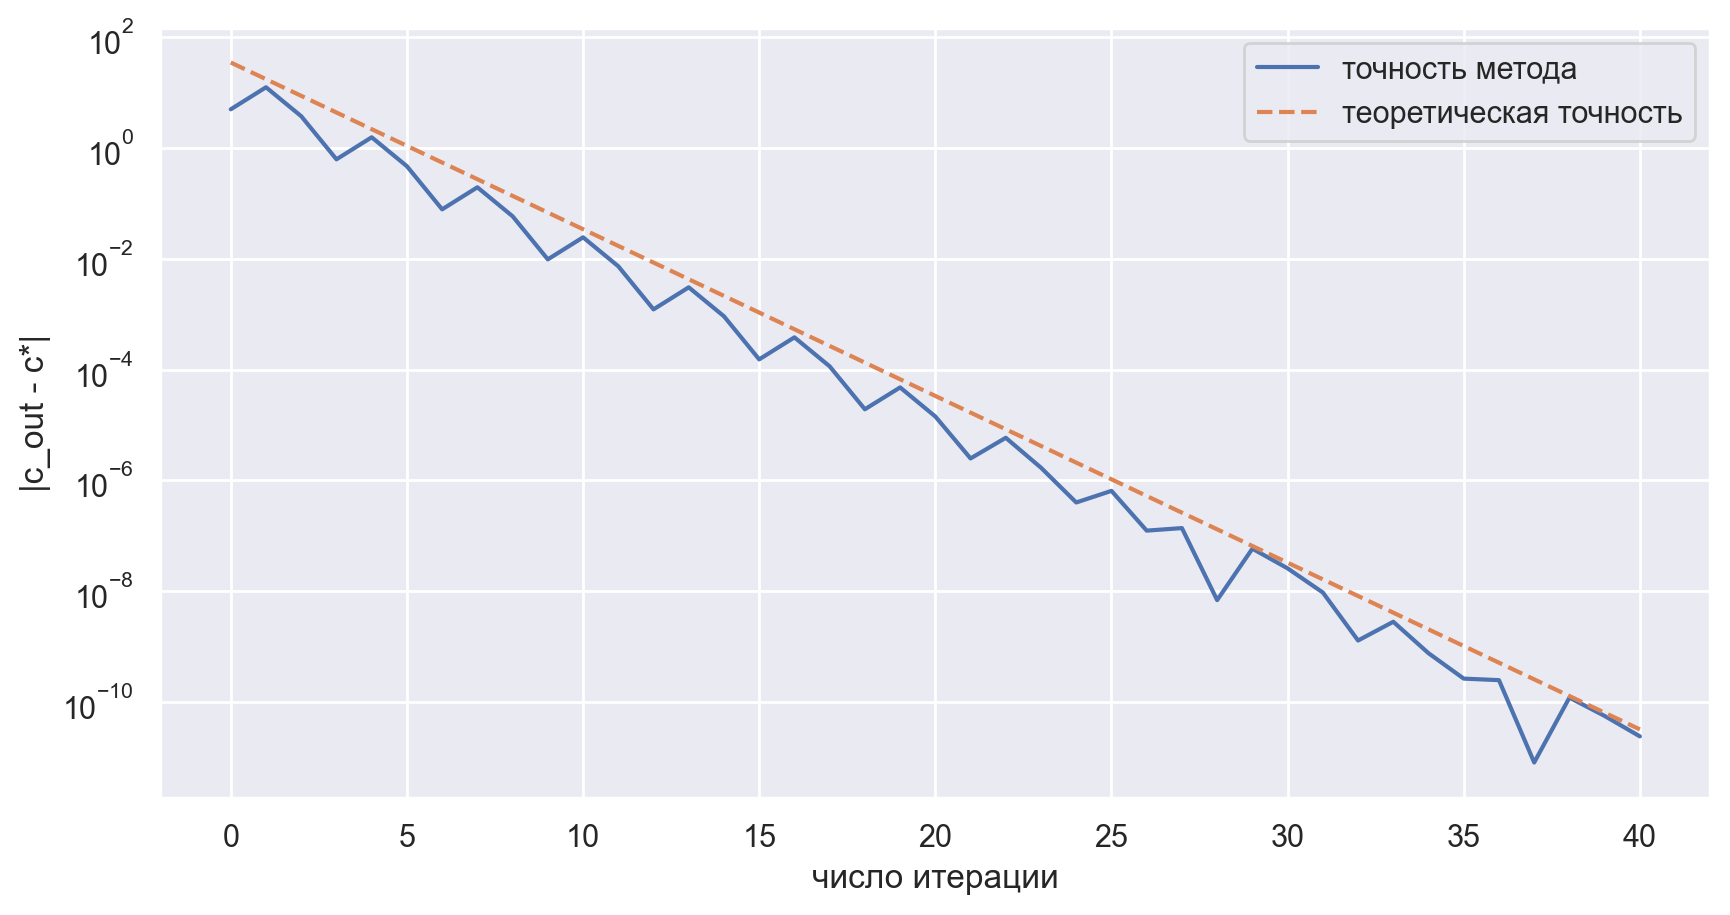

In [5]:
func = lambda x : x**2
a = -30
b = 40
c_star = 0
delta = 1e-8 * (b - a)
c, history, _ = dichotomy_method(func, a, b, c_star, max_iter = 40, delta = delta)

size = len(history)
grid = np.arange(size)
teor = [(b-a) / 2**(k) for k in range(1, size + 1)]
plt.figure(figsize = (10, 5))
plt.plot(grid, history, label="точность метода")
plt.plot(grid, teor, label = "теоретическая точность", ls = "--")
plt.xlabel("число итерации")
plt.ylabel("|c_out - c*|")
plt.yscale("log")
plt.legend()
plt.show()

#### Ваше решение (Markdown)
Можно заметить как схожость сходимостей метода с теоритической оценкой

__д) (1 балл)__ Теперь сравним работу метода при разных значениях гиперпараметра $\delta$. Предлагается рассмотреть следующие значения:
1. $\delta = 10^{-12} \cdot (b - a)$;
2. $\delta = 10^{-9} \cdot (b - a)$;
3. $\delta = 10^{-6} \cdot (b - a)$;
4. $\delta = 10^{-3} \cdot (b - a)$;
5. $\delta = 10^{-1} \cdot (b - a)$.

Постройте сравнительный график зависимости критерия от номера итерации.

<Figure size 1000x500 with 0 Axes>

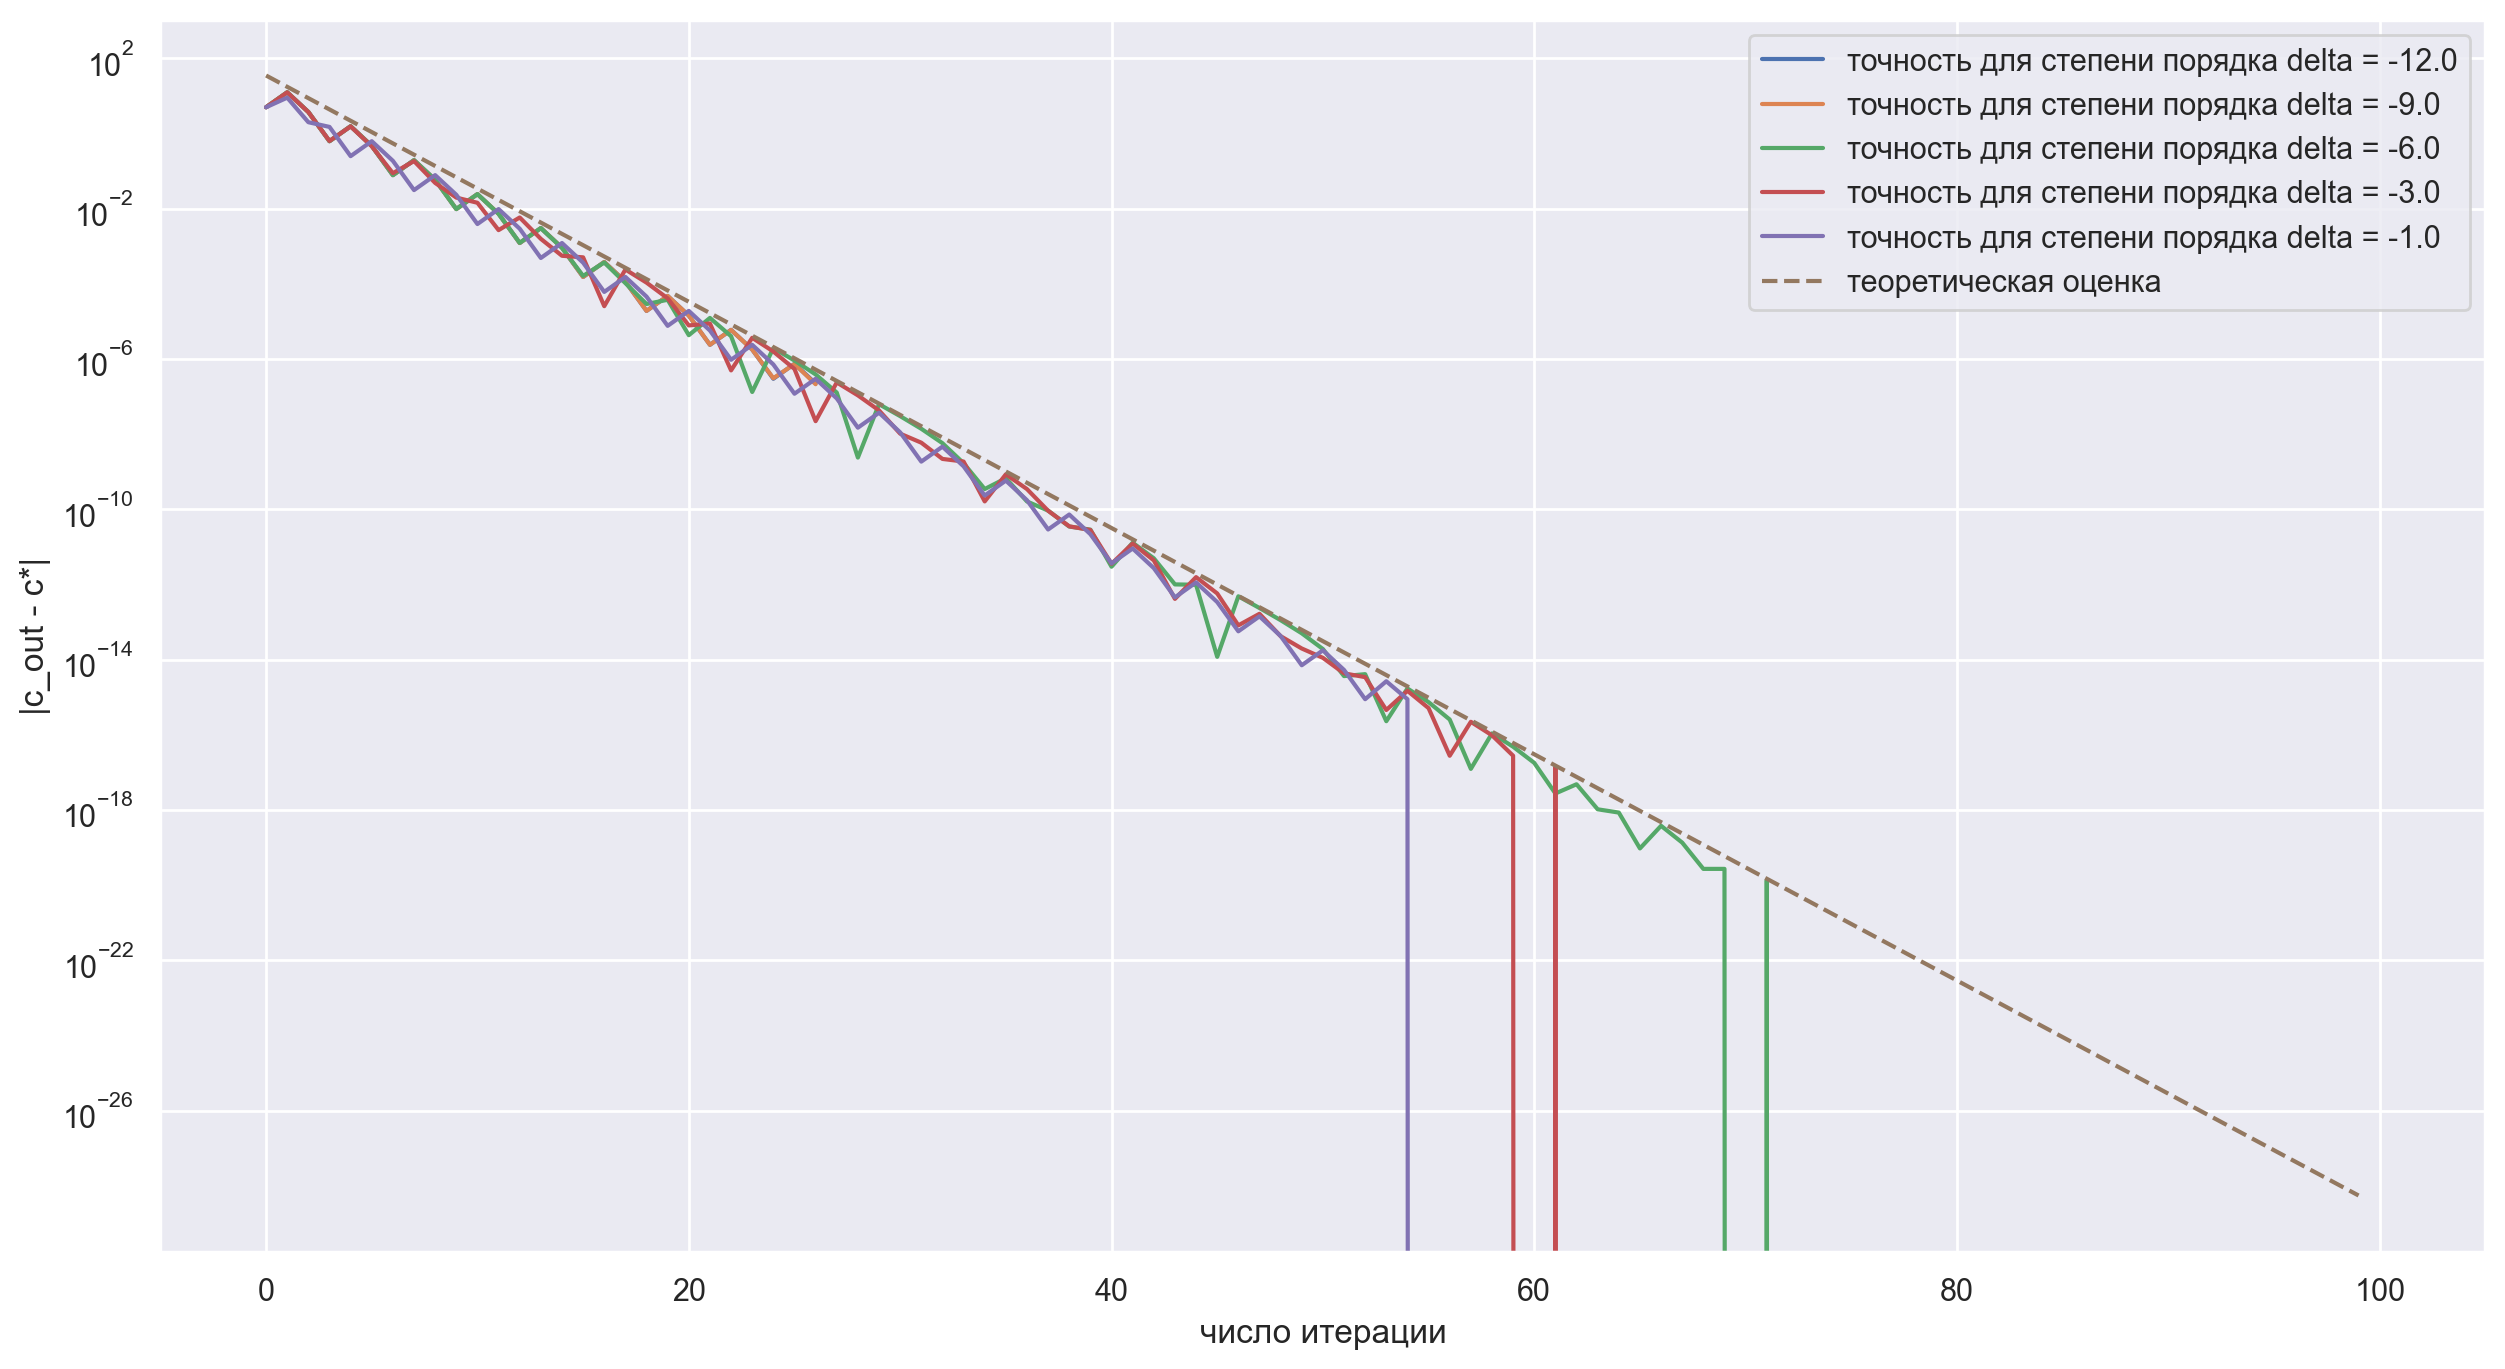

In [6]:
max_iter = 100
delta_list = [1e-12 * (b-a), 1e-9 * (b-a), 1e-6 * (b-a), 1e-3 * (b-a), 1e-1 * (b-a)]
plt.figure(figsize = (10, 5))
history_list = []
c_list = []

plt.figure(figsize = (15, 8))
for delta in delta_list:
  c, history, _ = dichotomy_method(func, a, b, c_star, max_iter=max_iter, delta = delta)
  c_list.append(c)
  history_list.append(history)
  size = len(history)
  grid = np.arange(size)
  plt.plot(grid, history, label=f"точность для степени порядка delta = {np.log10(delta / (b-a))}")

plt.plot(np.arange(max_iter), [(b-a) / 2**(k) for k in range(1, max_iter + 1)], ls = "--", label = "теоретическая оценка")
plt.yscale("log")
plt.xlabel("число итерации")
plt.ylabel("|c_out - c*|")
plt.legend()
plt.show()

Что можно сказать о зависимости сходимости от значения параметра $\delta$? Объясните, почему для малых значений наблюдается плохая сходимость. Для какого значения наблюдается наилучшая сходимость?

#### Ваше решение (Markdown)

у delta = 1e-3 наблюдаются крутые спуски что может говорить о его эффективности. С малыми значениями может прои

__e) (2 балла)__ До этого использовался подход с использованием постоянной величины $\delta$. Рассмотрим адаптивный подход, а именно - на каждой итерации значения $\delta$ будет определяться через длину интервала $l_k$, полученную на $k$-ой итерации. Предлагается рассмотреть следующие значения:

1. $\delta = 10^{-6} \cdot l_k$;
2. $\delta = 10^{-3} \cdot l_k$;
3. $\delta = 10^{-1} \cdot l_k$;
4. $\delta = 6^{-1} \cdot l_k$.

Последняя модификация также называется __тернарным__ поиском, при которой отрезок делится на 3 части на каждой итерации.

Постройте сравнительный график сходимости значения критерия от различных значений $\delta$. Также добавьте на график сходимость с наилучшим постоянным значением $\delta$, полученном в предыдущем пункте.

In [7]:
def dichotomy_adaptive(f, a, b, c_star, max_iter=100, epsilon=1e-6, **params):
    """
    Метод дихотомии для поиска минимума унимодальной функции на интервале [a, b].

    Параметры:
        f (callable): Унимодальная функция, минимум которой ищется.
        a (float): Левая граница интервала поиска.
        b (float): Правая граница интервала поиска.
        c_star (float): Истинное значение точки минимума (для сравнения).
        max_iter (int, optional): Максимальное количество итераций. По умолчанию 100.
        epsilon (float, optional): Точность поиска. 
            Поиск завершается, когда длина интервала становится меньше epsilon. По умолчанию 1e-6.
        **params: Именованные гиперпараметры метода.
            params['delta'](a, b) - функция, возвращающая значение интервала на k-ой итерации.

    Возвращает:
        c (float): Приближенное значение точки минимума.
        history (list): Список значений |c - c_star| на каждой итерации.
    """
    
    if a >= b:
        raise ValueError("Левая граница интервала a должна быть меньше правой границы b.")
    if epsilon <= 0:
        raise ValueError("Точность epsilon должна быть положительной.")
        
    history = []
    f_call = 0
    f_call_list = []

    # YOUR CODE HERE
    left = a
    right = b
    delta_func = params["delta"] # передаваемый параметр будет порядком delta
    iter = 0
    while(right - left > epsilon and iter <= max_iter): #   np.abs(left + (right - left) / 2 - c_star)
        delta = delta_func(left, right)
        c = left + (right - left) / 2
        f1 = f(c - delta)
        f2 = f(c + delta)
        f_call += 2
        f_call_list.append(f_call)
        history.append(np.abs(c - c_star))
        if(f1 < f2):
            right = c + delta
        else: 
            left = c - delta # здесь я совместил условия на f1 == f2 и f1 > f2 так как по алгоритму мы можем использовать один из двух вариантов по умолчанию
        iter += 1

    return c, history, f_call_list

<Figure size 1000x500 with 0 Axes>

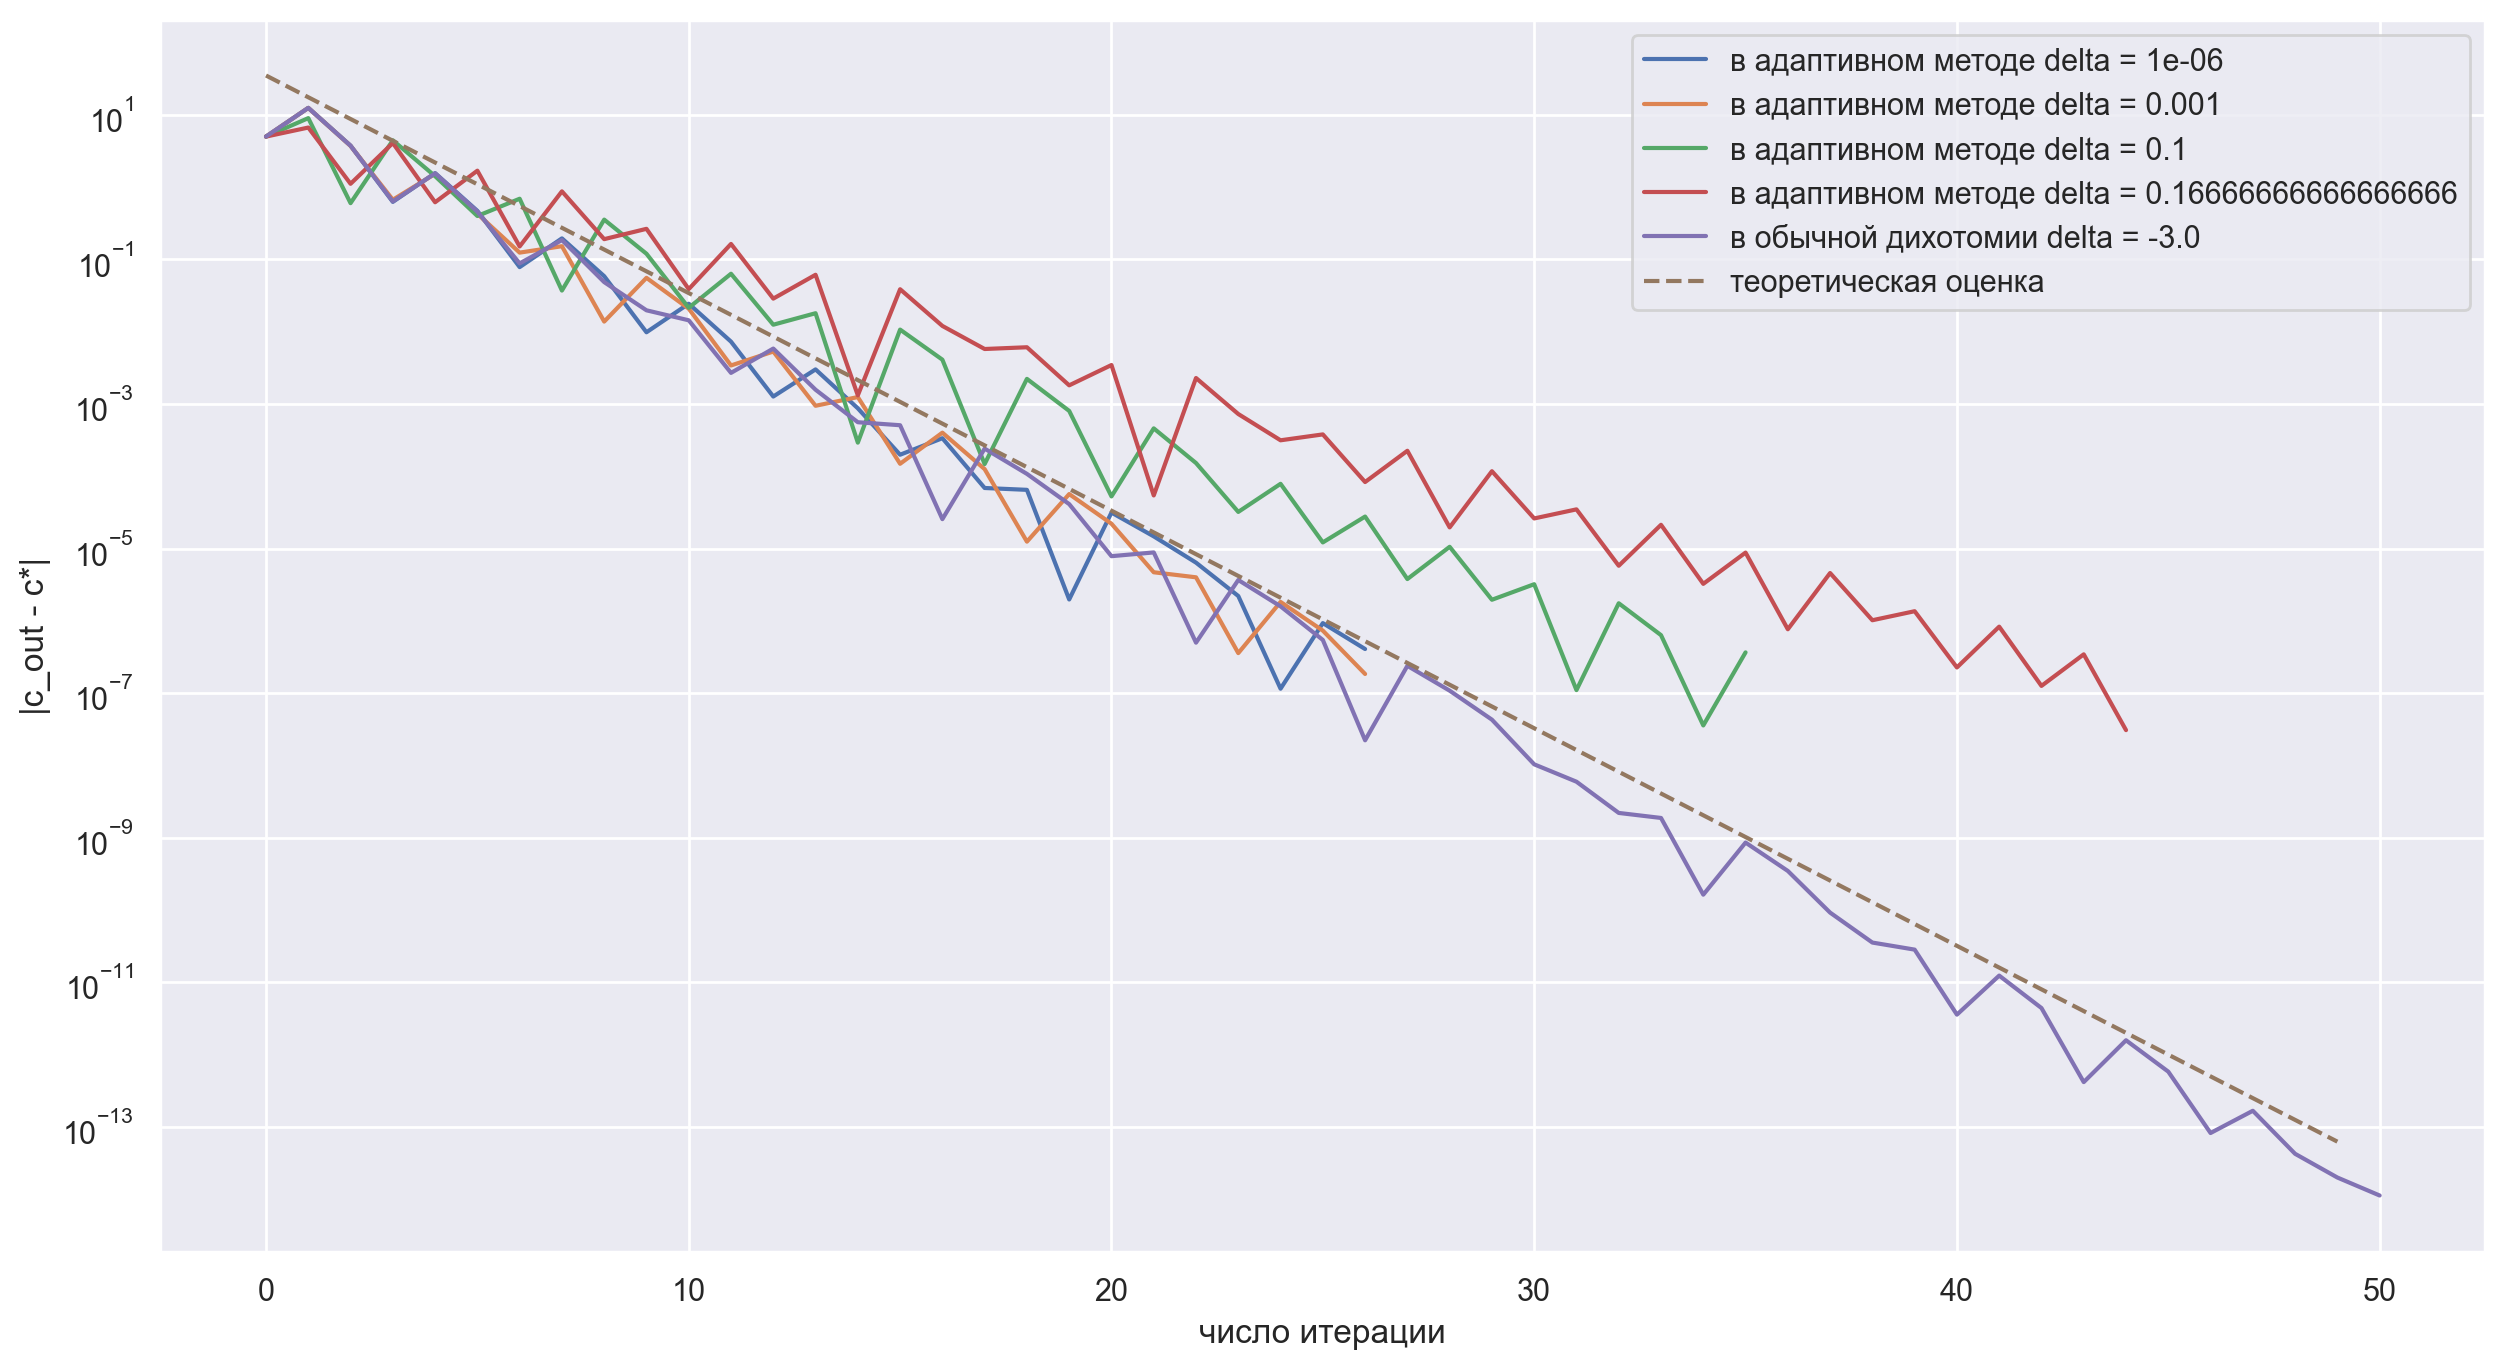

In [8]:
max_iter = 50
hyperparametrs = [1e-6, 1e-3, 1e-1, 1/6]
delta_func_list =  [lambda a, b, h_param = h_param : h_param * (b - a) for h_param in hyperparametrs]
plt.figure(figsize = (10, 5))
history_list = []
c_list = []

plt.figure(figsize = (15, 8))
for h_param, delta in zip(hyperparametrs, delta_func_list):
  c, history, _ = dichotomy_adaptive(func, a, b, c_star, max_iter=max_iter, delta = delta)
  c_list.append(c)
  history_list.append(history)
  size = len(history)
  grid = np.arange(size)
  plt.plot(grid, history, label=f"в адаптивном методе delta = {h_param}")

c, history, _ = dichotomy_method(func, a, b, c_star, max_iter=max_iter, delta = 1e-3 * (b - a))
c_list.append(c)
history_list.append(history)
size = len(history)
grid = np.arange(size)
plt.plot(grid, history, label=f"в обычной дихотомии delta = {np.log10(1e-3)}")

plt.plot(np.arange(max_iter), [(b-a) / 2**(k) for k in range(1, max_iter + 1)], ls = "--", label = "теоретическая оценка")
plt.yscale("log")
plt.xlabel("число итерации")
plt.ylabel("|c_out - c*|")
plt.legend()
plt.show()

Помогает ли использование адаптивного подхода в достижении лучшей сходимости?

#### Ваше решение (Markdown)

с крупными $ \delta $ метод стал сходится медленее. Мне кажется тут так же значение $ \delta = 10^{-3} * l_{k}$ выглядит наилучшим вариантом, так как в нем присутсвуют стабильные крутые спуски по сравнению с синим графиком где спуски кажутс довольно крутыми, но не такими частыми как у оранжевого

__ё) (2 балла)__ Реализуйте метод __золотого сечения__. Для этого на каждой итерации подсчитываются точки $x_{1}, x_{2}$, симметричные относительно середины интервала и делящие исходный интервал в пропорции золотого сечения, то есть 1 к $\frac{1 + \sqrt{5}}{2}$. Обновления краевого значения происходит по аналогичной процедуре. 

In [9]:
def golden_ration_method(f, a, b, c_star, epsilon=1e-6):
    """
    Метод золотого сечения для поиска минимума унимодальной функции на интервале [a, b].

    Параметры:
        f (callable): Унимодальная функция, минимум которой ищется.
        a (float): Левая граница интервала поиска.
        b (float): Правая граница интервала поиска.
        c_star (float): Истинное значение точки минимума (для сравнения).
        epsilon (float, optional): Точность поиска. 
            Поиск завершается, когда длина интервала становится меньше epsilon. По умолчанию 1e-6.

    Возвращает:
        c (float): Приближенное значение точки минимума.
        history (list): Список значений |c - c_star| на каждой итерации.
    """
    
    if a >= b:
        raise ValueError("Левая граница интервала a должна быть меньше правой границы b.")
    if epsilon <= 0:
        raise ValueError("Точность epsilon должна быть положительной.")

    history = []
    f_call = 0
    f_call_list = []
    golden_ration = (1 + np.sqrt(5)) / 2

    # YOUR CODE HERE
    
    left = a
    right = b

    x1 = (left * golden_ration + right * 1) / (1 + golden_ration)
    x2 = (left * 1 + right * golden_ration) / (1 + golden_ration)
    c = left + (right - left) / 2
    f1 = f(x1)
    f2 = f(x2)
    f_call += 2
    f_call_list.append(f_call)
    history.append(np.abs(c - c_star))

    if(f1 < f2):
        f2 = f1
        f1 = f((left * golden_ration + x2 * 1) / (1 + golden_ration))
        right = x2
    else:
        f1 = f2
        f2 = f((x1 * 1 + right * golden_ration) / (1 + golden_ration))
        left = x1

    while(right - left > epsilon):
        x1 = (left * golden_ration + right * 1) / (1 + golden_ration)
        x2 = (left * 1 + right * golden_ration) / (1 + golden_ration)
        c = left + (right - left) / 2
        history.append(np.abs(c - c_star))
        
        if(f1 < f2):
            f2 = f1
            f1 = f((left * golden_ration + x2 * 1) / (1 + golden_ration))
            right = x2
        else:
            f1 = f2
            f2 = f((x1 * 1 + right * golden_ration) / (1 + golden_ration))
            left = x1
        f_call += 1
        f_call_list.append(f_call)


    return c, history, f_call_list

Постройте график сходимости.

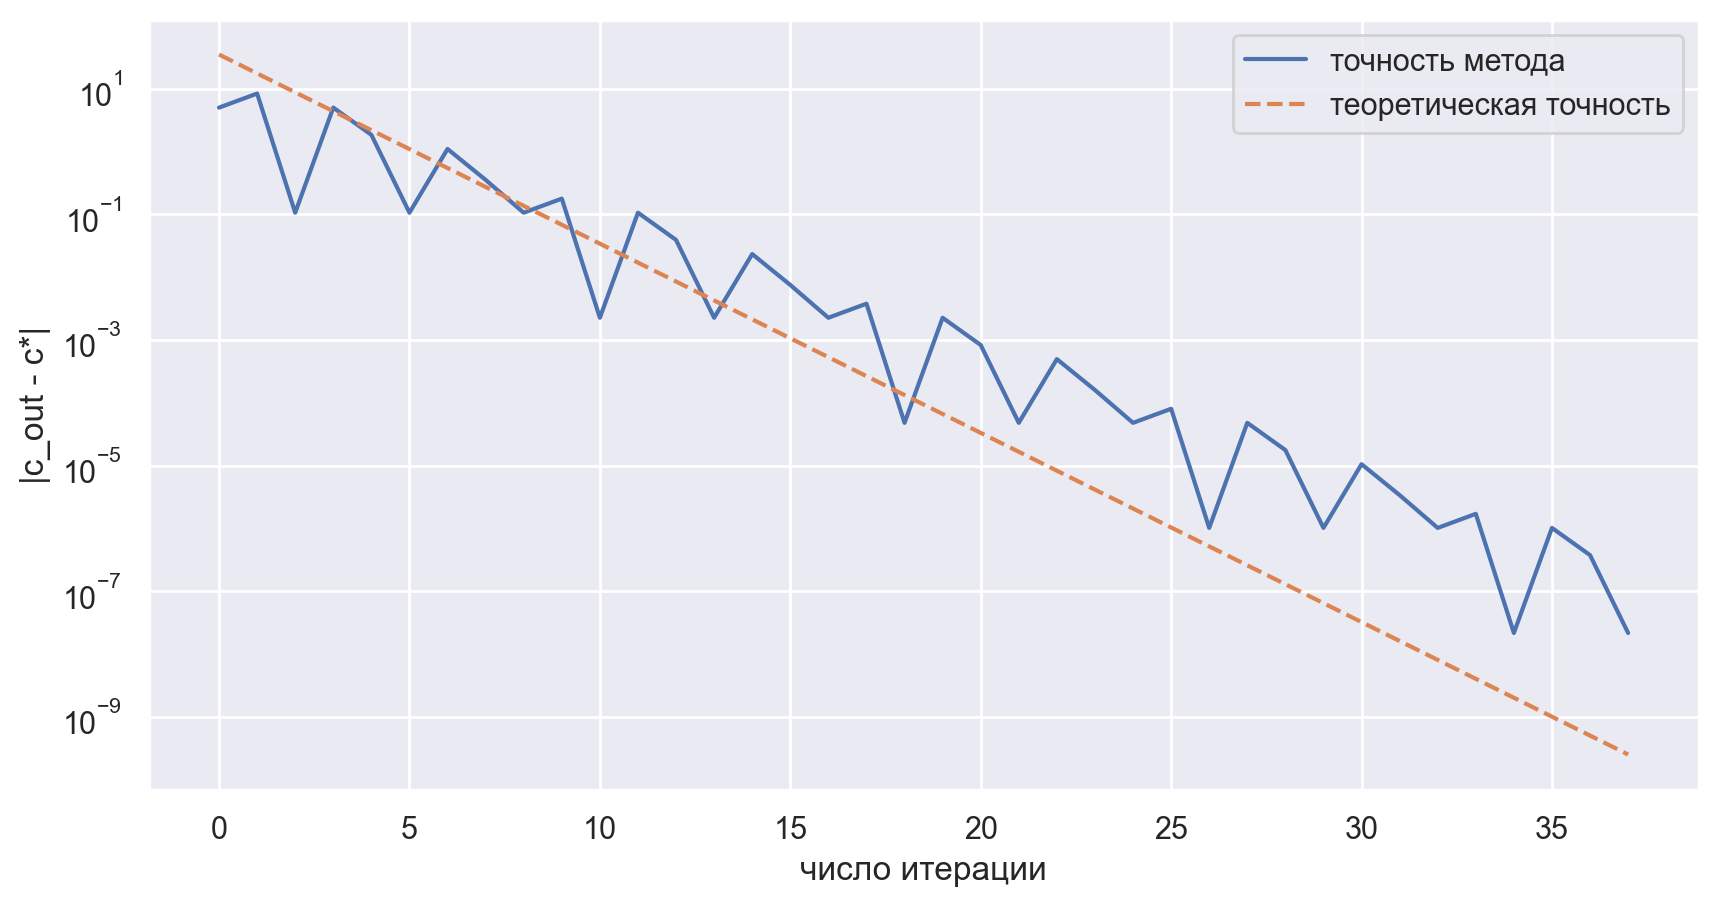

In [10]:
# Ваше решение (Code)

func = lambda x : x**2
a = -30
b = 40
c_star = 0
c, history, _ = golden_ration_method(func, a, b, c_star)

size = len(history)
grid = np.arange(size)
teor = [(b-a) / 2**(k) for k in range(1, size + 1)]
plt.figure(figsize = (10, 5))
plt.plot(grid, history, label="точность метода")
plt.plot(grid, teor, label = "теоретическая точность", ls = "--")
plt.xlabel("число итерации")
plt.ylabel("|c_out - c*|")
plt.yscale("log")
plt.legend()
plt.show()

__ж) (1.5 балла)__ Постройте сравнительные графики для методов ```dichotomy_method```, ```dichotomy_adaptive``` и ```golden_ratio_method``` для оптимальных значений параметра $\delta$. Первый график должен быть значением критерия от числа итераций.

In [11]:
max_iter = 50
func = lambda x : x**2
a = -30
b = 40
c_star = 0

c_orig, history_orig, orig_call_list = dichotomy_method(func, a, b, c_star, max_iter =max_iter, delta = 1e-3 * (b-a))
c_adapt, history_adapt, adapt_call_list = dichotomy_adaptive(func, a, b, c_star, max_iter = max_iter, delta = lambda a, b : 1e-3 * (b-a))
c_gold, history_gold, gold_call_list = golden_ration_method(func, a, b, c_star)

orig_size = len(history_orig)
adapt_size = len(history_adapt)
gold_size = len(history_gold)

In [12]:
orig_size
len(orig_call_list)

51

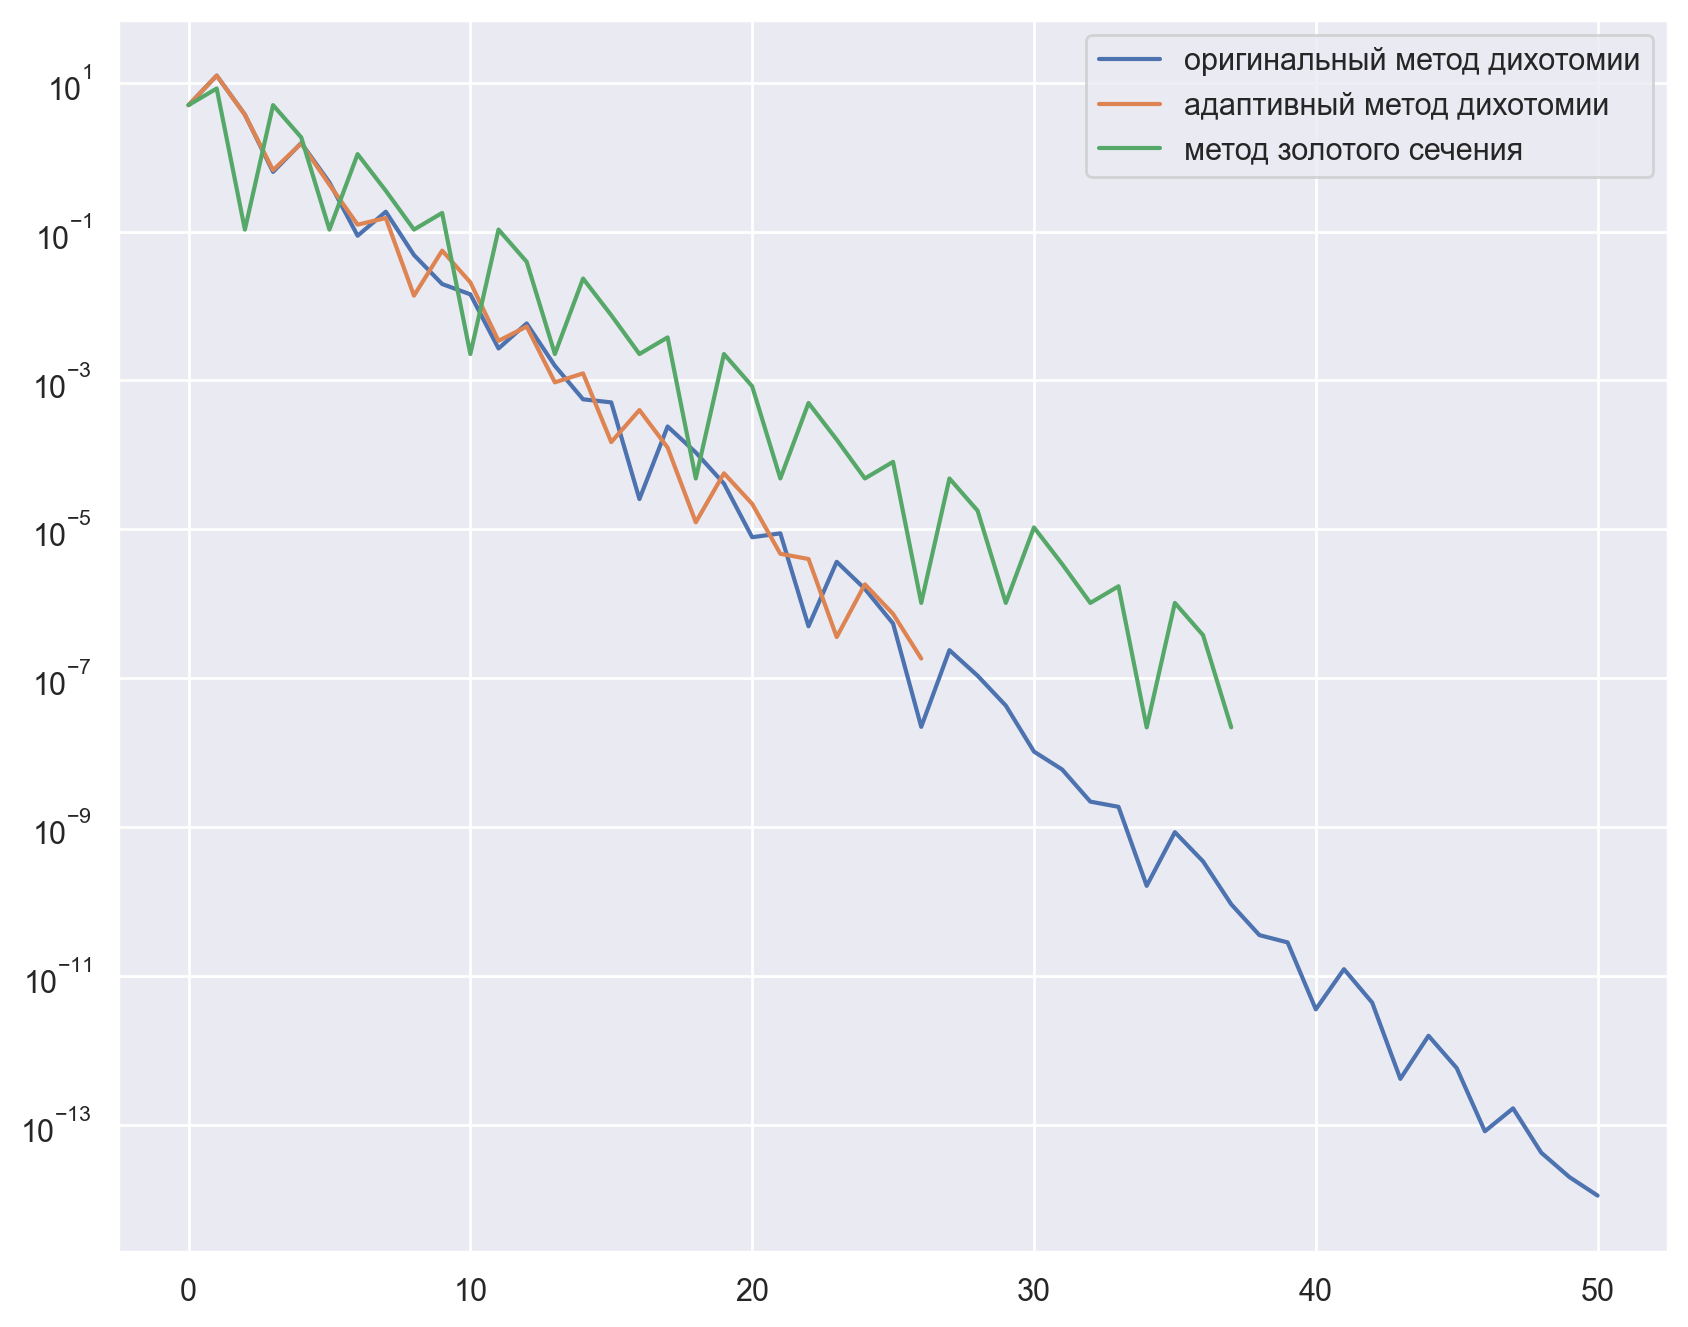

In [13]:
# Ваше решение (Code)

plt.figure(figsize = (10, 8))
plt.plot(np.arange(orig_size), history_orig, label = "оригинальный метод дихотомии")
plt.plot(np.arange(adapt_size), history_adapt, label = "адаптивный метод дихотомии")
plt.plot(np.arange(gold_size), history_gold, label = "метод золотого сечения")
plt.legend()
plt.yscale("log")

Второй - критерий от количества вызовов функции $f$.

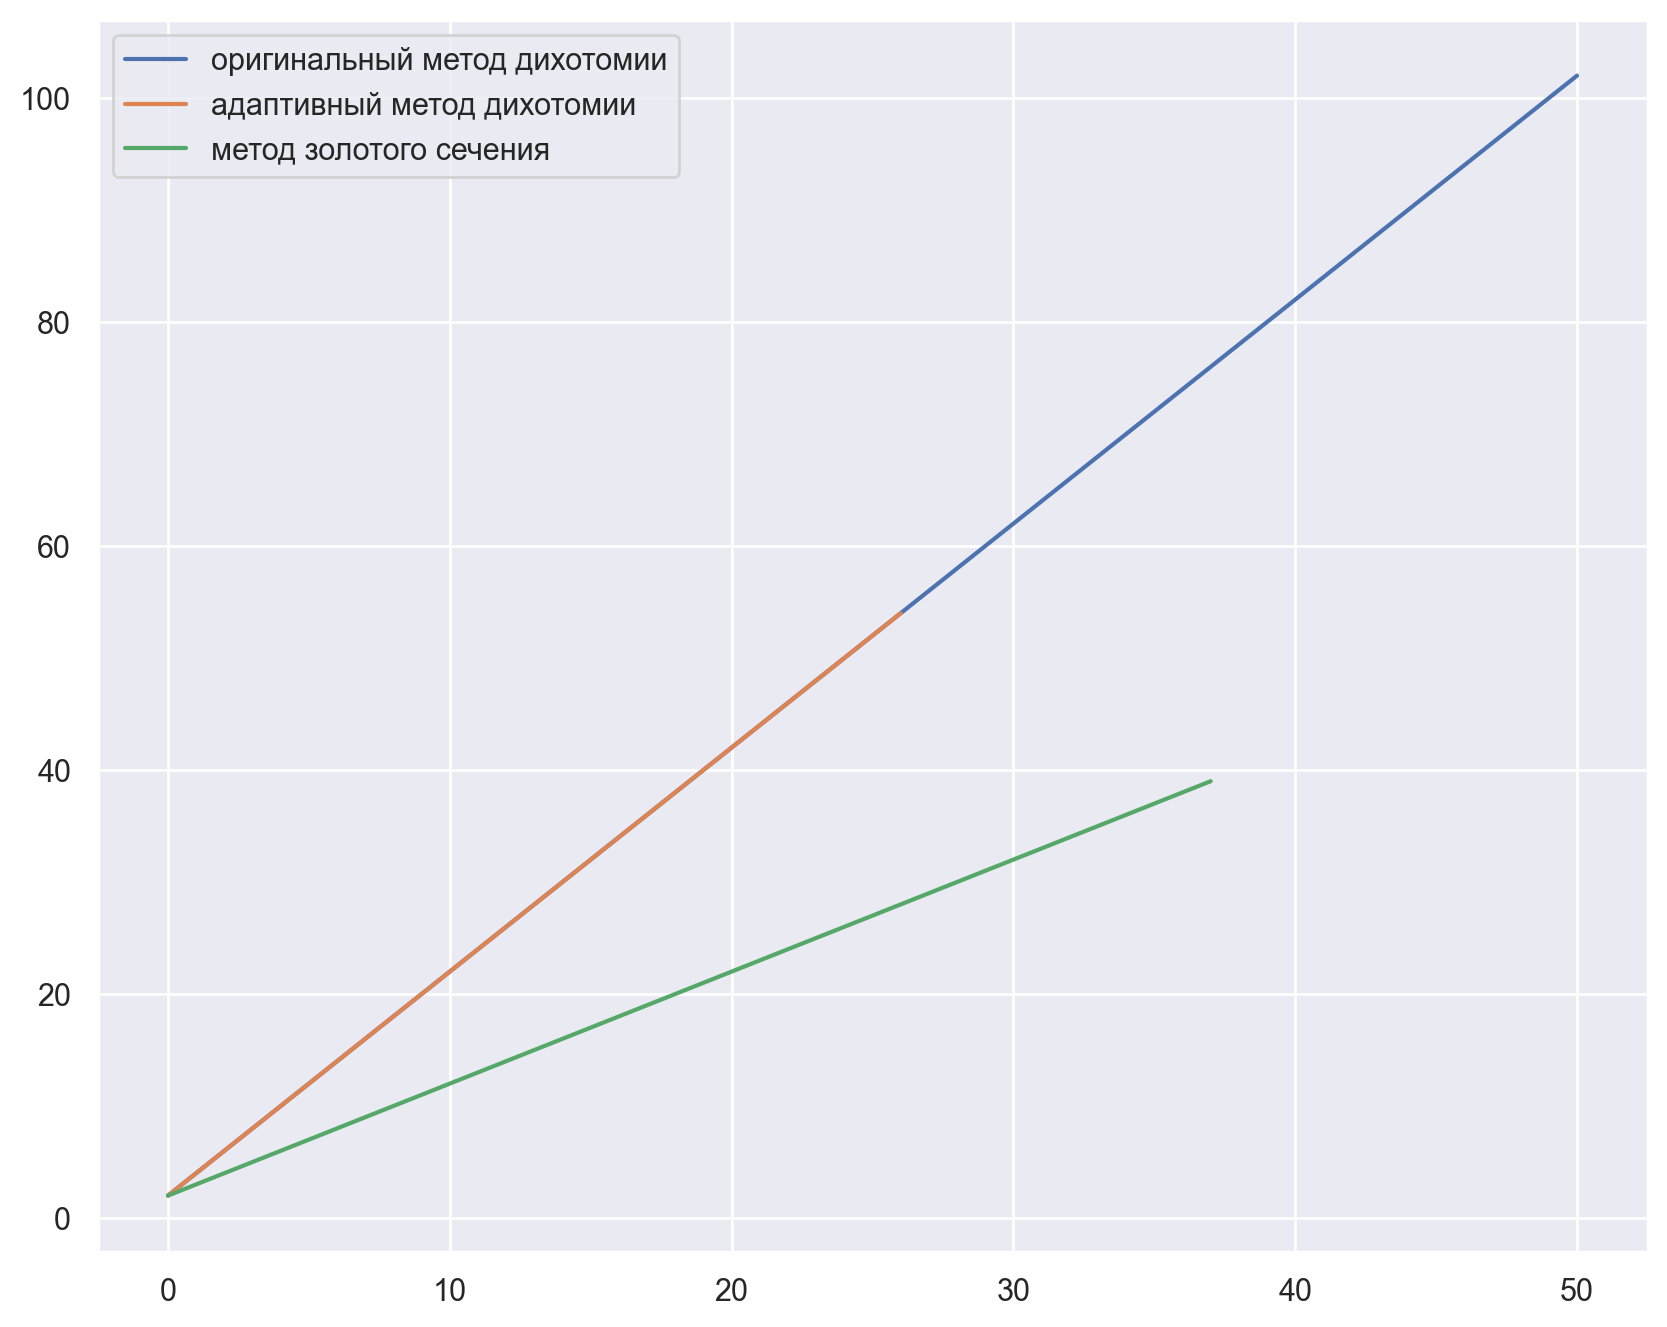

In [14]:
# Ваше решение (Code)

plt.figure(figsize = (10, 8))
plt.plot(np.arange(orig_size), orig_call_list, label = "оригинальный метод дихотомии")
plt.plot(np.arange(adapt_size), adapt_call_list, label = "адаптивный метод дихотомии")
plt.plot(np.arange(gold_size), gold_call_list, label = "метод золотого сечения")
plt.legend()

Что можно сказать о применимости метода золотого сечения? В чем он лучше по сравнению с методом дихотомии? 

#### Ваше решение (Markdown)

как мы могли заметить то метод золотого сечения сходится медленнее остольных методов, но использует исследуемую функцию в два раза меньше, это может пригодится когда вызов оракула требует больших ресурсов и мы можем смирится с увеличением итерации.